In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

# 3 years of weekly data
n_weeks = 156
dates = pd.date_range('2022-01-03', periods=n_weeks, freq='W-MON')

df = pd.DataFrame({'date': dates})

# Seasonality: yearly cycle + a holiday bump around weeks 47-51 (Nov/Dec)
week_of_year = df['date'].dt.isocalendar().week.astype(int)
seasonality = 1 + 0.25 * np.sin(2 * np.pi * week_of_year / 52)
holiday_bump = np.where((week_of_year >= 47) & (week_of_year <= 51), 1.4, 1.0)

# Underlying trend (slow growth over 3 years)
trend = np.linspace(1.0, 1.3, n_weeks)

# Marketing spend per channel (with some realistic variation and occasional zero-spend weeks)
tv_spend = np.clip(np.random.normal(8000, 2000, n_weeks), 0, None)
paid_search_spend = np.clip(np.random.normal(5000, 1200, n_weeks), 0, None)
paid_social_spend = np.clip(np.random.normal(4000, 1500, n_weeks), 0, None)
display_spend = np.clip(np.random.normal(2000, 800, n_weeks), 0, None)
promo_spend = np.clip(np.random.normal(1500, 1000, n_weeks), 0, None)

df['tv_spend'] = tv_spend
df['paid_search_spend'] = paid_search_spend
df['paid_social_spend'] = paid_social_spend
df['display_spend'] = display_spend
df['promo_spend'] = promo_spend

# Price index (small random fluctuations)
df['price_index'] = np.clip(np.random.normal(1.0, 0.05, n_weeks), 0.85, 1.15)

df.head()

,date,tv_spend,paid_search_spend,paid_social_spend,display_spend,promo_spend,price_index
0,2022-01-03,8993.428306,7238.929413,5238.124523,1575.599082,3093.186627,1.008885
1,2022-01-10,7723.471398,5568.599505,5220.264454,1539.345407,988.784324,0.933233
2,2022-01-17,9295.377076,3570.435803,5958.218211,1779.958642,510.395180,1.019010
3,2022-01-24,11046.059713,5787.864330,4031.505762,158.463068,1374.213080,1.030529
4,2022-01-31,7531.693251,3830.381996,5022.929457,787.847150,1555.724912,1.027990


In [2]:
def adstock(spend, decay):
    """Applies geometric adstock: this week's effect = spend + decay * last week's effect"""
    adstocked = np.zeros_like(spend)
    adstocked[0] = spend[0]
    for t in range(1, len(spend)):
        adstocked[t] = spend[t] + decay * adstocked[t-1]
    return adstocked

def saturate(x, alpha, gamma):
    """Hill saturation curve: diminishing returns as spend increases"""
    return x**alpha / (x**alpha + gamma**alpha)

# True parameters we're "hiding" in the data — the model should approximately recover these
true_params = {
    'tv':          {'decay': 0.5, 'alpha': 2.0, 'gamma': 15000, 'beta': 3000},
    'paid_search': {'decay': 0.2, 'alpha': 2.5, 'gamma': 8000,  'beta': 4500},
    'paid_social': {'decay': 0.4, 'alpha': 2.0, 'gamma': 7000,  'beta': 2500},
    'display':     {'decay': 0.3, 'alpha': 1.8, 'gamma': 3000,  'beta': 800},
    'promo':       {'decay': 0.1, 'alpha': 1.5, 'gamma': 2000,  'beta': 1200},
}

channels = ['tv', 'paid_search', 'paid_social', 'display', 'promo']
channel_contribution = pd.DataFrame(index=df.index)

for ch in channels:
    spend = df[f'{ch}_spend'].values
    p = true_params[ch]
    adstocked = adstock(spend, p['decay'])
    saturated = saturate(adstocked, p['alpha'], p['gamma'])
    channel_contribution[ch] = p['beta'] * saturated

# Baseline sales (what you'd sell with zero marketing): trend * seasonality * holiday, plus a price effect
baseline = 20000 * trend * seasonality * holiday_bump * (df['price_index'] ** -1.5)

# Total sales = baseline + all channel contributions + noise
noise = np.random.normal(0, 800, n_weeks)
df['sales'] = baseline + channel_contribution.sum(axis=1) + noise

# keep contributions around for later validation
contributions_true = channel_contribution.copy()
contributions_true['baseline'] = baseline

df[['date', 'sales']].describe()
df.head()

,date,tv_spend,paid_search_spend,paid_social_spend,display_spend,promo_spend,price_index,sales
0,2022-01-03,8993.428306,7238.929413,5238.124523,1575.599082,3093.186627,1.008885,24155.655114
1,2022-01-10,7723.471398,5568.599505,5220.264454,1539.345407,988.784324,0.933233,29183.984268
2,2022-01-17,9295.377076,3570.435803,5958.218211,1779.958642,510.395180,1.019010,26079.531287
3,2022-01-24,11046.059713,5787.864330,4031.505762,158.463068,1374.213080,1.030529,26516.052515
4,2022-01-31,7531.693251,3830.381996,5022.929457,787.847150,1555.724912,1.027990,25932.639869


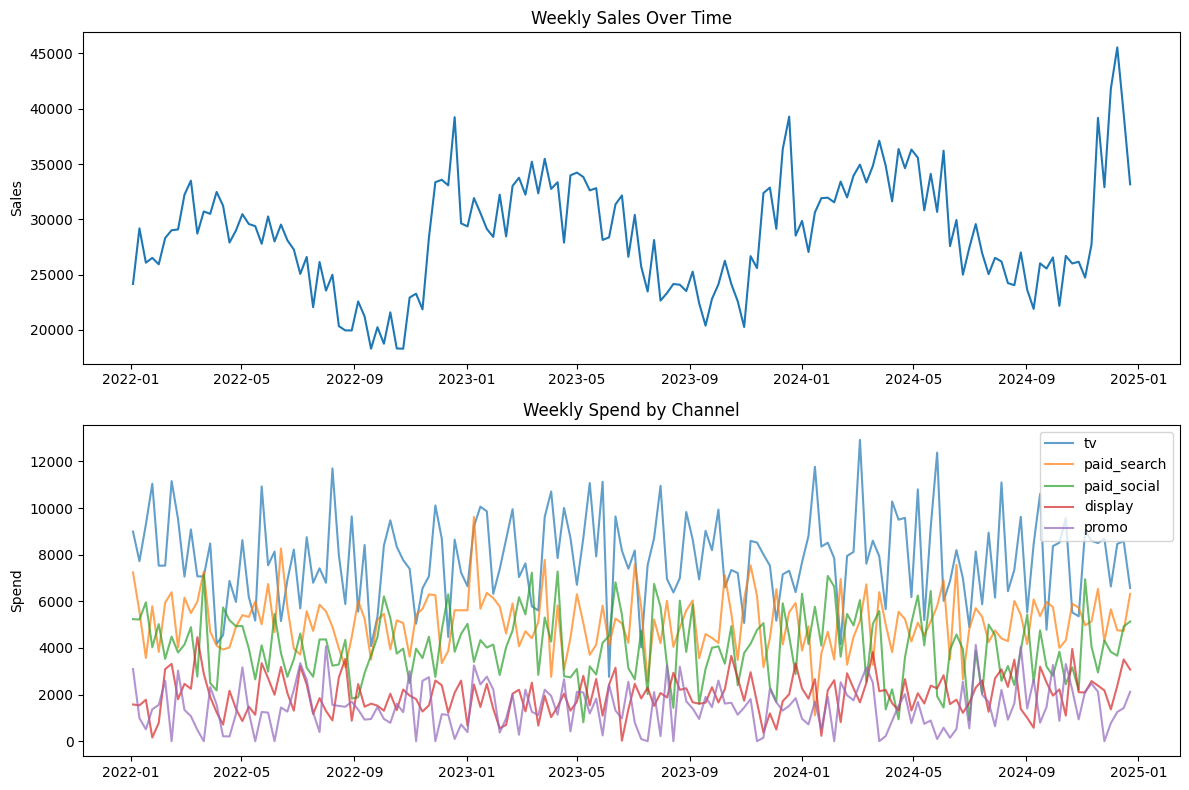

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(df['date'], df['sales'])
axes[0].set_title('Weekly Sales Over Time')
axes[0].set_ylabel('Sales')

for ch in channels:
    axes[1].plot(df['date'], df[f'{ch}_spend'], label=ch, alpha=0.7)
axes[1].set_title('Weekly Spend by Channel')
axes[1].set_ylabel('Spend')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/charts/data_overview.png', dpi=100)
plt.show()

In [4]:
df.to_csv('../data/raw/mmm_weekly_data.csv', index=False)
contributions_true.to_csv('../data/processed/true_contributions.csv', index=False)